# **Predicting Loan Payback**
This notebook tackles Playground Series S5E11 – [https://www.kaggle.com/competitions/playground-series-s5e11](http://)

* EDA
* Preprocessing
* Feature engineering
* Modeling
* Ensemble ...
* Stacking ...


# 1. Import Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

from lightgbm import LGBMClassifier
import lightgbm as lgb
from scipy.stats import uniform, randint
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# 2. Import Train, Test, Submission_Sample Files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
sub = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [3]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
df_train.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [4]:
#Droping "id" column
train = train.drop("id", axis=1)
test = test.drop("id", axis=1)

# 3. EDA

In [5]:
print(f"df Train shape {train.shape}")
print(f"df Test shape {test.shape}")

df Train shape (593994, 12)
df Test shape (254569, 11)


In [6]:
pd.set_option('display.max_columns', None)
train.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0



## Check Null and Duplicate Values


In [7]:
print("Number of null value in Train DF : ",train.isna().sum().sum())
print("Number of null value in Test DF : ",test.isna().sum().sum())


Number of null value in Train DF :  0
Number of null value in Test DF :  0


In [8]:
#Check Duplicate Rows
print("Number of Duplicated Row in Train DF : ", train.duplicated().sum())


Number of Duplicated Row in Train DF :  0


## Divide Numerical and Categorical Columns

In [9]:
num_cols = train.select_dtypes(exclude= 'object').columns

cat_cols = train.select_dtypes(include= 'object').columns


print(f"\n Numerical features + Target ({len(num_cols)}):")
for i, col in enumerate(num_cols, 1):
    print(f"   {i}. {col}")
print("="*50)
print(f"\n Categorical features ({len(cat_cols)}):")
for i, col in enumerate(cat_cols, 1):
    print(f"   {i}. {col}")

print(f"\n Total  features: {len(num_cols) + len(cat_cols)}")


 Numerical features + Target (6):
   1. annual_income
   2. debt_to_income_ratio
   3. credit_score
   4. loan_amount
   5. interest_rate
   6. loan_paid_back

 Categorical features (6):
   1. gender
   2. marital_status
   3. education_level
   4. employment_status
   5. loan_purpose
   6. grade_subgrade

 Total  features: 12


## Numerical Features Analyse

In [10]:
train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


In [11]:
type(num_cols)

pandas.core.indexes.base.Index

### Correlation

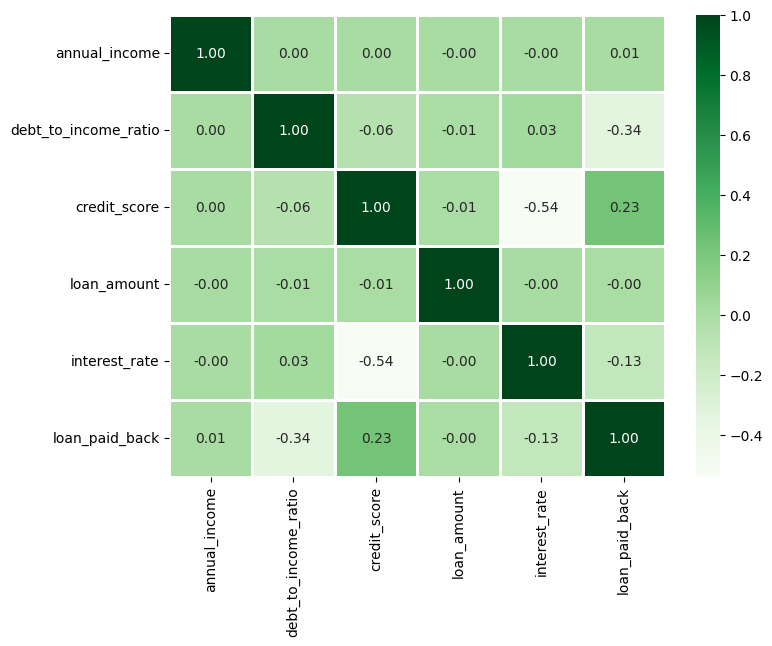

In [12]:
# numerical features correlation
plt.figure(figsize=(8, 6))
correlation_matrix = train[num_cols ].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            linewidths=1, cmap="Greens")
plt.show()

In [13]:
#Droping Target column
num_cols=num_cols.drop('loan_paid_back')

### Distribution and Outlier

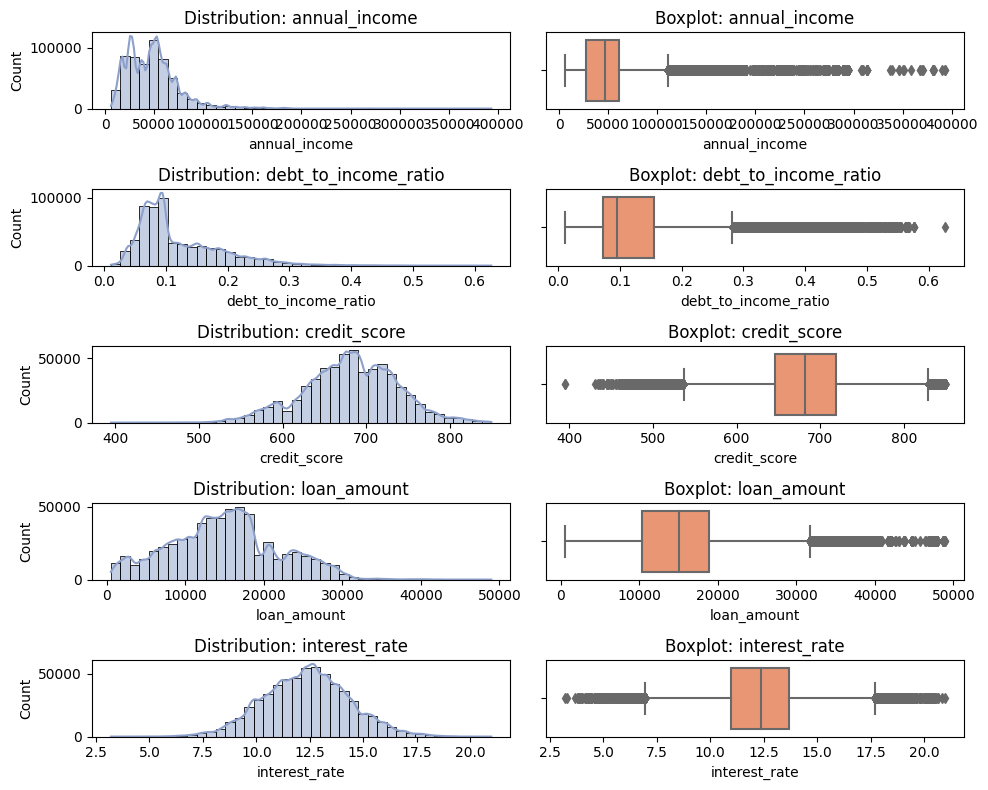

In [14]:
plt.figure(figsize=(10, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 2, 2*i - 1)
    sns.histplot(train[col], kde=True, bins=40, color="#8da0cb")
    plt.title(f'Distribution: {col}')

    plt.subplot(len(num_cols), 2, 2*i)
    sns.boxplot(x=train[col], color="#fc8d62")
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

### Train vs Test (distribution drift)

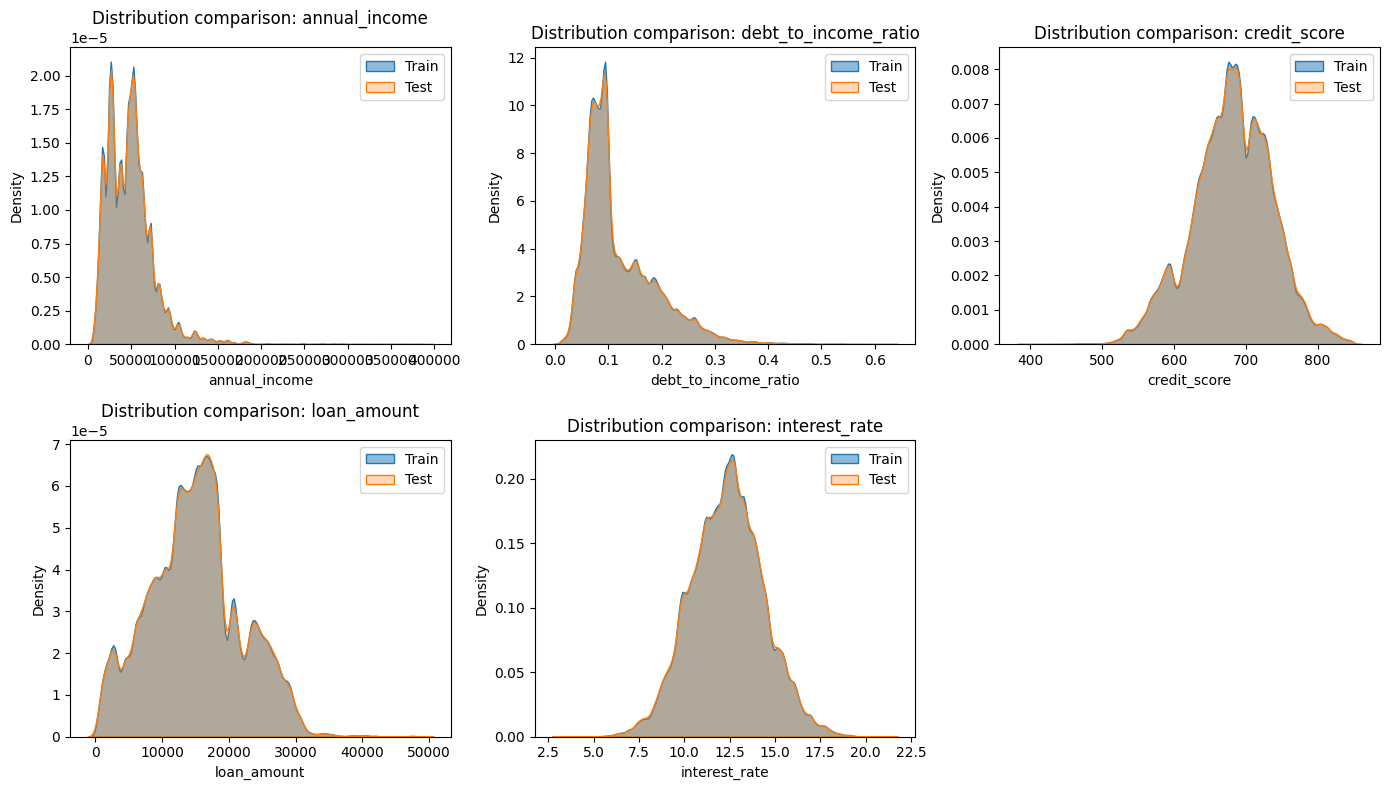

In [15]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.kdeplot(train[col], label='Train', fill=True, alpha=0.5)
    sns.kdeplot(test[col], label='Test', fill=True, alpha=0.3)
    plt.title(f'Distribution comparison: {col}')
    plt.legend()
plt.tight_layout()
plt.show()

## Explore the Target Variable

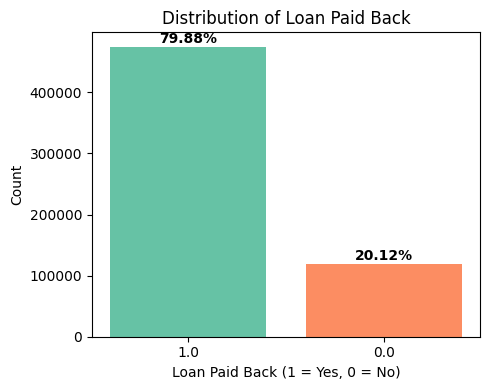

In [16]:
# 1. Basic counts
target_counts = train['loan_paid_back'].value_counts()

# 2. Percentages
target_percent = train['loan_paid_back'].value_counts(normalize=True) * 100

target_counts = train['loan_paid_back'].value_counts()
target_percent = train['loan_paid_back'].value_counts(normalize=True) * 100

# 2. Plot
plt.figure(figsize=(5,4))
bars = plt.bar(target_counts.index.astype(str),
               target_counts.values,
               color=['#66c2a5','#fc8d62'])

# Add percentage labels on each bar
for bar in bars:
    height = bar.get_height()
    percent = (height / target_counts.sum()) * 100
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,  # adjust '1000' if scale differs
             f'{percent:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribution of Loan Paid Back')
plt.xlabel('Loan Paid Back (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##  Class Imbalance

**This is a moderately imbalanced dataset — about 80/20 split.**

**That means:**

There are much fewer “default” cases (0.0).

A naive model that always predicts “1.0” (paid back) would already get ~80% accuracy — but terrible ROC-AUC because it can’t rank risk properly.

*So roughly 4 out of 5 loans are successfully repaid, and 1 out of 5 defaults.*

## Categorical Feature Analyse


=== GENDER ===

Summary:
         Count  Repayment_Rate
gender                        
Female  306175        0.801708
Male    284091        0.795752
Other     3728        0.795333


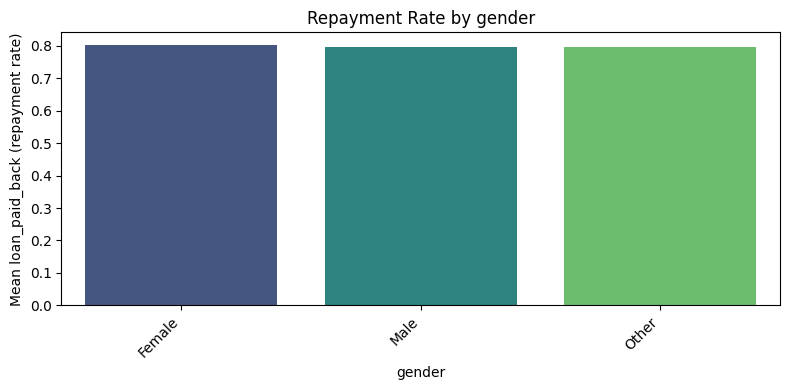


=== MARITAL_STATUS ===

Summary:
                 Count  Repayment_Rate
marital_status                        
Single          288843        0.798873
Married         277239        0.799144
Divorced         21312        0.796640
Widowed           6600        0.789848


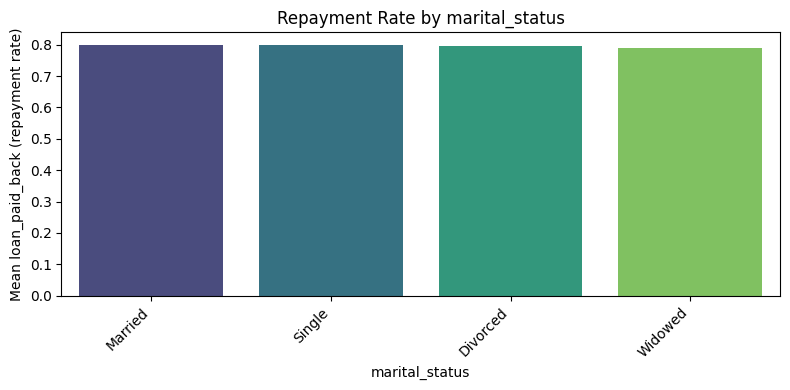


=== EDUCATION_LEVEL ===

Summary:
                  Count  Repayment_Rate
education_level                        
Bachelor's       279606        0.788892
High School      183592        0.809698
Master's          93097        0.802346
Other             26677        0.802789
PhD               11022        0.830067


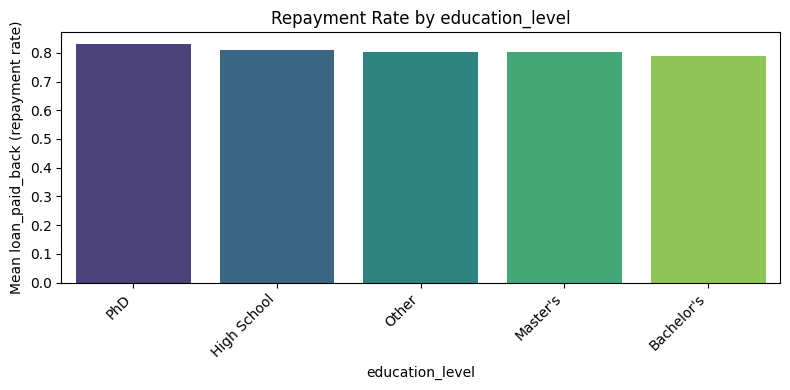


=== EMPLOYMENT_STATUS ===

Summary:
                    Count  Repayment_Rate
employment_status                        
Employed           450645        0.894145
Unemployed          62485        0.077619
Self-employed       52480        0.898457
Retired             16453        0.997204
Student             11931        0.263515


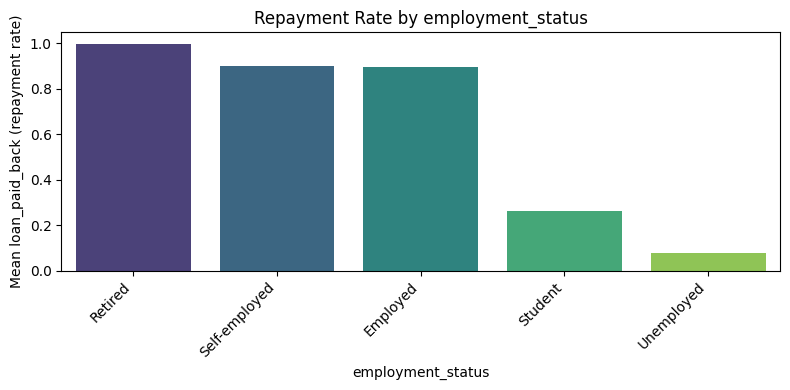


=== LOAN_PURPOSE ===

Summary:
                     Count  Repayment_Rate
loan_purpose                              
Debt consolidation  324695        0.796911
Other                63874        0.802377
Car                  58108        0.800630
Home                 44118        0.823224
Education            36641        0.777053
Business             35303        0.813104
Medical              22806        0.778085
Vacation              8449        0.796071


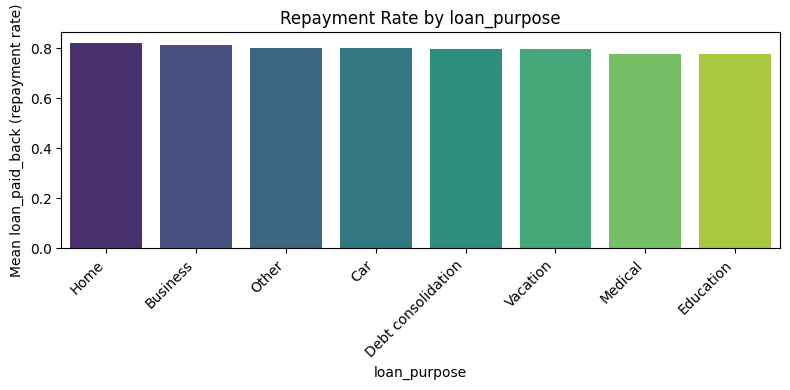


=== GRADE_SUBGRADE ===

Summary:
                Count  Repayment_Rate
grade_subgrade                       
C3              58695        0.836000
C4              55957        0.843987
C2              54443        0.851165
C1              53363        0.860090
C5              53317        0.846259
D1              37029        0.731886
D3              36694        0.695972
D4              35097        0.714733
D2              34432        0.720957
D5              32101        0.713000
B2              15167        0.937430
B1              14344        0.916341
B5              13937        0.934204
B3              13926        0.940040
B4              13877        0.931758
E4               8036        0.649577
E3               7075        0.641837
E1               6891        0.652010
E2               6372        0.662743
E5               6084        0.669461
F5               5947        0.639314
F4               5535        0.637037
F1               5534        0.624503
F2              

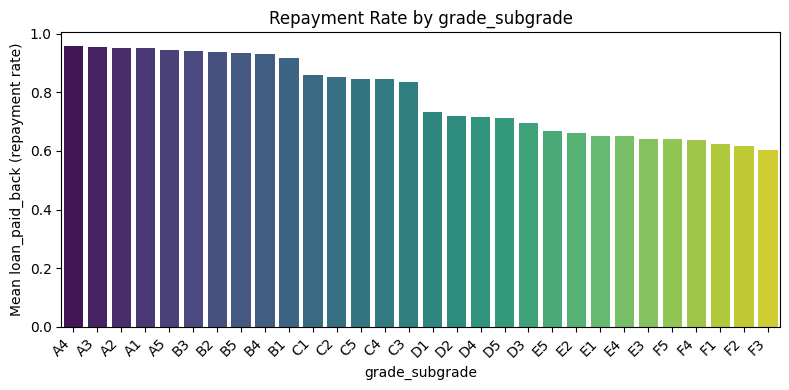

In [17]:
for col in cat_cols:
    print(f"\n=== {col.upper()} ===")
    
    # Frequency table
    freq = train[col].value_counts(dropna=False)
  
    
    # Repayment rate (mean of target per category)
    repayment_rate = train.groupby(col)['loan_paid_back'].mean().sort_values(ascending=False)

    
    # Combine both 
    summary = pd.concat([freq, repayment_rate], axis=1)
    summary.columns = ['Count', 'Repayment_Rate']
    print("\nSummary:")
    print(summary)
    
    # --- Visualization ---
    plt.figure(figsize=(8,4))
    
    # Bar for repayment rate (target mean)
    sns.barplot(
        x=repayment_rate.index,
        y=repayment_rate.values,
        palette="viridis"
    )
    plt.title(f'Repayment Rate by {col}')
    plt.ylabel('Mean loan_paid_back (repayment rate)')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [18]:
train.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


# 4. Preprocessing


###  Skewness


In [19]:
from scipy.stats import skew

skew_values = train[num_cols].apply(lambda x: skew(x.dropna()))
print(skew_values.sort_values(ascending=False))

annual_income           1.719504
debt_to_income_ratio    1.406676
loan_amount             0.207359
interest_rate           0.049945
credit_score           -0.166992
dtype: float64


In [20]:
skewed_cols = skew_values[abs(skew_values) > 1].index.tolist()
print("Highly skewed columns:", skewed_cols)

for col in skewed_cols:
    train[col] = np.log1p(train[col])
    test[col]  = np.log1p(test[col])

from sklearn.preprocessing import PowerTransformer

# Initialize Yeo-Johnson transformer
pt = PowerTransformer(method='yeo-johnson')

# Apply transformation to skewed columns
# train[skewed_cols] = pt.fit_transform(train[skewed_cols])
# test[skewed_cols] = pt.transform(test[skewed_cols])

Highly skewed columns: ['annual_income', 'debt_to_income_ratio']


### outliers (IQR)

In [21]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)

In [22]:
target = 'loan_paid_back'
cols = train.columns
cols = cols.drop('loan_paid_back')

## Target Encoding

thanks to yousef Elshahat

[https://www.kaggle.com/code/yousefelshahat2/simple-xgboost-only-competition-data-s5e11/notebook](http://)

In [23]:
def target_encoding(train, predict, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    mean_features_train = pd.DataFrame(index=train.index)
    mean_features_test = pd.DataFrame(index=predict.index)

    for col in cols:
        # --- K-Fold Target Mean Encoding ---
        mean_encoded = np.zeros(len(train))
        for tr_idx, val_idx in kf.split(train):
            tr_fold = train.iloc[tr_idx]
            val_fold = train.iloc[val_idx]
            mean_map = tr_fold.groupby(col)[target].mean()
            mean_encoded[val_idx] = val_fold[col].map(mean_map)

        mean_features_train[f'mean_{col}'] = mean_encoded

        # --- Apply global mean mapping to prediction/test data ---
        global_mean = train.groupby(col)[target].mean()
        mean_features_test[f'mean_{col}'] = predict[col].map(global_mean)

    # --- Concatenate new features at once to avoid fragmentation ---
    train = pd.concat([train, mean_features_train], axis=1)
    predict = pd.concat([predict, mean_features_test], axis=1)

    # Defragment
    train = train.copy()
    predict = predict.copy()
    return train, predict

train , test = target_encoding(train, test)

## Add Frequency Feature

thanks to yousef Elshahat

[https://www.kaggle.com/code/yousefelshahat2/simple-xgboost-only-competition-data-s5e11/notebook](http://)

In [24]:
def create_frequency_features(df, df_test):

    # Pre-allocate DataFrames for new features to avoid fragmentation
    freq_features_train = pd.DataFrame(index=df.index)
    freq_features_test = pd.DataFrame(index=df_test.index)
    bin_features_train = pd.DataFrame(index=df.index)
    bin_features_test = pd.DataFrame(index=df_test.index)

    for col in cols:
        # --- Frequency encoding ---
        freq = df[col].value_counts()
        df[f"{col}_freq"] = df[col].map(freq)
        freq_features_test[f"{col}_freq"] = df_test[col].map(freq).fillna(freq.mean())

        # --- Quantile binning for numeric columns ---
        if col in num_cols:
            for q in [5, 10, 15]:
                try:
                    train_bins, bins = pd.qcut(df[col], q=q, labels=False, retbins=True, duplicates="drop")
                    bin_features_train[f"{col}_bin{q}"] = train_bins
                    bin_features_test[f"{col}_bin{q}"] = pd.cut(df_test[col], bins=bins, labels=False, include_lowest=True)
                except Exception:
                    bin_features_train[f"{col}_bin{q}"] = 0
                    bin_features_test[f"{col}_bin{q}"] = 0

    # Concatenate all new features at once
    df = pd.concat([df, freq_features_train, bin_features_train], axis=1)
    df_test = pd.concat([df_test, freq_features_test, bin_features_test], axis=1)

    return df, df_test

train, test = create_frequency_features(train, test)

In [25]:
train.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,mean_annual_income,mean_debt_to_income_ratio,mean_credit_score,mean_loan_amount,mean_interest_rate,mean_gender,mean_marital_status,mean_education_level,mean_employment_status,mean_loan_purpose,mean_grade_subgrade,annual_income_freq,debt_to_income_ratio_freq,credit_score_freq,loan_amount_freq,interest_rate_freq,gender_freq,marital_status_freq,education_level_freq,employment_status_freq,loan_purpose_freq,grade_subgrade_freq,annual_income_bin5,annual_income_bin10,annual_income_bin15,debt_to_income_ratio_bin5,debt_to_income_ratio_bin10,debt_to_income_ratio_bin15,credit_score_bin5,credit_score_bin10,credit_score_bin15,loan_amount_bin5,loan_amount_bin10,loan_amount_bin15,interest_rate_bin5,interest_rate_bin10,interest_rate_bin15
0,10.287695,0.080658,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.710526,0.847686,0.895262,0.875000,0.726531,0.802141,0.798951,0.809686,0.899948,0.802012,0.835339,51,6720,3472,57,933,306175,288843,183592,52480,63874,58695,1,2,4,1,3,5,4,8,12,0,0,0,3,7,11
1,10.003741,0.153579,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.923077,0.627424,0.649867,0.714286,0.710706,0.795659,0.799032,0.802114,0.894201,0.796389,0.695845,16,2677,3825,44,552,284091,277239,93097,450645,324695,36694,0,1,2,3,7,11,0,1,2,0,0,1,3,6,9
2,10.811085,0.092579,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,NaN,0.816124,0.813119,0.825000,0.915512,0.795738,0.798951,0.809686,0.894132,0.797286,0.847443,1,9508,4025,48,923,284091,288843,183592,450645,324695,53317,2,5,8,2,5,7,2,5,8,3,6,9,0,0,1
3,10.754904,0.062975,536.5,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,NaN,0.904502,0.575928,0.818182,0.747475,0.802255,0.799220,0.809999,0.894269,0.797795,0.626351,1,6114,4065,60,250,306175,288843,183592,450645,324695,5534,2,5,7,0,1,2,0,0,0,0,0,1,4,9,14
4,10.146344,0.051643,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.923077,0.914669,0.836411,0.875000,0.881429,0.795659,0.799032,0.809371,0.894201,0.802117,0.732244,19,5292,3388,78,896,284091,277239,183592,450645,63874,37029,1,2,3,0,0,1,1,3,5,1,3,5,0,1,2


# 5. Feature Engineering

**[https://www.kaggle.com/code/analyticaobscura/s5e11-loan-payback-xgb-lgbm-ann](http://)**

In [26]:

# train['loan_to_income'] = train['loan_amount'] / (train['annual_income'] + 1)
# test['loan_to_income'] = test['loan_amount'] / (test['annual_income'] + 1)

# train['total_debt'] = train['debt_to_income_ratio'] * train['annual_income']
# test['total_debt'] = test['debt_to_income_ratio'] * test['annual_income']

# train['available_income'] = train['annual_income'] * (1 - train['debt_to_income_ratio'])
# test['available_income'] = test['annual_income'] * (1 - test['debt_to_income_ratio'])

# train['affordability'] = train['available_income'] / (train['loan_amount'] + 1)
# test['affordability'] = test['available_income'] / (test['loan_amount'] + 1)

# train['monthly_payment'] = train['loan_amount'] * (1 + train['interest_rate']/100) / 12
# test['monthly_payment'] = test['loan_amount'] * (1 + test['interest_rate']/100) / 12

# train['payment_to_income'] = train['monthly_payment'] / (train['annual_income']/12 + 1)
# test['payment_to_income'] = test['monthly_payment'] / (test['annual_income']/12 + 1)

# train['risk_score'] = (train['debt_to_income_ratio'] * 40 + 
#                        (1 - train['credit_score']/850) * 30 + train['interest_rate'] * 2)
# test['risk_score'] = (test['debt_to_income_ratio'] * 40 + 
#                       (1 - test['credit_score']/850) * 30 + test['interest_rate'] * 2)


# train['credit_interest'] = train['credit_score'] * train['interest_rate'] / 100
# test['credit_interest'] = test['credit_score'] * test['interest_rate'] / 100

# train['income_credit'] = np.log1p(train['annual_income']) * train['credit_score'] / 1000
# test['income_credit'] = np.log1p(test['annual_income']) * test['credit_score'] / 1000

# train['debt_loan'] = train['debt_to_income_ratio'] * np.log1p(train['loan_amount'])
# test['debt_loan'] = test['debt_to_income_ratio'] * np.log1p(test['loan_amount'])

# train['log_income'] = np.log1p(train['annual_income'])
# test['log_income'] = np.log1p(test['annual_income'])

# train['log_loan'] = np.log1p(train['loan_amount'])
# test['log_loan'] = np.log1p(test['loan_amount'])

# for df in [train, test]:
#     df['income_to_dti'] = df['annual_income'] / (1 + df['debt_to_income_ratio'])
#     df['interest_to_score'] = df['interest_rate'] / df['credit_score']
#     df['loan_per_score'] = df['loan_amount'] / df['credit_score']
#     df['loan_to_dti'] = df['loan_amount'] / (1 + df['debt_to_income_ratio'])


# # credit score categories

def map_fico_tier(score):
    """Maps a credit score to its corresponding FICO tier."""
    if score >= 800:
        return 'Exceptional'
    elif score >= 740:
        return 'Very Good'
    elif score >= 670:
        return 'Good'
    elif score >= 580:
        return 'Fair'
    else: # Below 580
        return 'Poor'

def map_vantage_tier(score):
    """Maps a credit score to its corresponding VantageScore tier."""
    if score >= 781:
        return 'Excellent'
    elif score >= 661:
        return 'Good'
    elif score >= 601:
        return 'Fair'
    elif score >= 500:
        return 'Poor'
    else: # Below 500
        return 'Very Poor'

# Creates two new categorical features based on FICO and VantageScore ranges 
# using the existing 'credit_score' column in both train and test DataFrames.

# for data in [train, test]:
#     data['credit_score_FICO_tier'] = data['credit_score'].apply(map_fico_tier)
#     data['credit_score_Vantage_tier'] = data['credit_score'].apply(map_vantage_tier)


## Encode Categortical Columns

**1. grade_subgrade Split** : A1 is the best credit, F5 is the riskiest


* A1	       -----Excellent borrower, safest
* A5	       -----Slightly lower credit quality
* B1	       -----Moderate risk
* D4	       -----Risky
* F5	       -----Very high risk

**2. Onehot other categorical column**

In [27]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

train['grade'] = train['grade_subgrade'].str[0]
train['subgrade'] = train['grade_subgrade'].str[1:].astype(int)

test['grade'] = test['grade_subgrade'].str[0]
test['subgrade'] = test['grade_subgrade'].str[1:].astype(int)

grade_order = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
train['grade'] = train['grade'].map(grade_order)
test['grade'] = test['grade'].map(grade_order)

train = train.drop('grade_subgrade', axis =1)
test = test.drop('grade_subgrade', axis =1)


cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()
onehot_cols = cat_cols

# onehot_cols = ['gender', 'marital_status', 'education_level', 
#                'employment_status', 'loan_purpose']



# One-hot encode
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_train = ohe.fit_transform(train[onehot_cols])
encoded_test = ohe.transform(test[onehot_cols])

# Convert to DataFrame
encoded_train_df = pd.DataFrame(encoded_train, 
                                columns=ohe.get_feature_names_out(onehot_cols),
                                index=train.index)
encoded_test_df = pd.DataFrame(encoded_test, 
                               columns=ohe.get_feature_names_out(onehot_cols),
                               index=test.index)

# Concatenate back
train = pd.concat([train.drop(columns=onehot_cols), encoded_train_df], axis=1)
test = pd.concat([test.drop(columns=onehot_cols), encoded_test_df], axis=1)



In [28]:
train['credit_rank'] = train['grade'] * 10 + train['subgrade']
test['credit_rank']  = test['grade'] * 10 + test['subgrade']


In [29]:
X = train.drop(columns='loan_paid_back',axis=1)
y = train['loan_paid_back']

In [30]:
X.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,mean_annual_income,mean_debt_to_income_ratio,mean_credit_score,mean_loan_amount,mean_interest_rate,mean_gender,mean_marital_status,mean_education_level,mean_employment_status,mean_loan_purpose,mean_grade_subgrade,annual_income_freq,debt_to_income_ratio_freq,credit_score_freq,loan_amount_freq,interest_rate_freq,gender_freq,marital_status_freq,education_level_freq,employment_status_freq,loan_purpose_freq,grade_subgrade_freq,annual_income_bin5,annual_income_bin10,annual_income_bin15,debt_to_income_ratio_bin5,debt_to_income_ratio_bin10,debt_to_income_ratio_bin15,credit_score_bin5,credit_score_bin10,credit_score_bin15,loan_amount_bin5,loan_amount_bin10,loan_amount_bin15,interest_rate_bin5,interest_rate_bin10,interest_rate_bin15,grade,subgrade,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,credit_rank
0,10.287695,0.080658,736.0,2528.42,13.67,0.710526,0.847686,0.895262,0.875000,0.726531,0.802141,0.798951,0.809686,0.899948,0.802012,0.835339,51,6720,3472,57,933,306175,288843,183592,52480,63874,58695,1,2,4,1,3,5,4,8,12,0,0,0,3,7,11,3,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,33
1,10.003741,0.153579,636.0,4593.10,12.92,0.923077,0.627424,0.649867,0.714286,0.710706,0.795659,0.799032,0.802114,0.894201,0.796389,0.695845,16,2677,3825,44,552,284091,277239,93097,450645,324695,36694,0,1,2,3,7,11,0,1,2,0,0,1,3,6,9,4,3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,43
2,10.811085,0.092579,694.0,17005.15,9.76,NaN,0.816124,0.813119,0.825000,0.915512,0.795738,0.798951,0.809686,0.894132,0.797286,0.847443,1,9508,4025,48,923,284091,288843,183592,450645,324695,53317,2,5,8,2,5,7,2,5,8,3,6,9,0,0,1,3,5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,35
3,10.754904,0.062975,536.5,4682.48,16.10,NaN,0.904502,0.575928,0.818182,0.747475,0.802255,0.799220,0.809999,0.894269,0.797795,0.626351,1,6114,4065,60,250,306175,288843,183592,450645,324695,5534,2,5,7,0,1,2,0,0,0,0,0,1,4,9,14,6,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,61
4,10.146344,0.051643,665.0,12184.43,10.21,0.923077,0.914669,0.836411,0.875000,0.881429,0.795659,0.799032,0.809371,0.894201,0.802117,0.732244,19,5292,3388,78,896,284091,277239,183592,450645,63874,37029,1,2,3,0,0,1,1,3,5,1,3,5,0,1,2,4,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,41


# 6. Modeling

## 1. LightGBM 

In [31]:
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import roc_auc_score, roc_curve
# from lightgbm import LGBMClassifier

# params = dict(
#     n_estimators=1320,
#     learning_rate=0.05,
#     num_leaves=93,
#     max_depth=5,
#     colsample_bytree=0.975,
#     subsample=0.743,
#     reg_alpha=2.95,
#     reg_lambda=0.0022,
#     random_state=42,
#     n_jobs=-1,
#     metric='auc',
#     objective='binary',
#     boosting_type='gbdt',
#     verbosity=-1,
# )

# oof_preds = np.zeros(len(X))
# test_preds = np.zeros(len(test))
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# roc_curves, fold_scores = [], []

# for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
#     print(f"--- Fold {fold}/{skf.n_splits} ---")
#     X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
#     y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

#     model = LGBMClassifier(**params)
#     model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_val, y_val)],
#         eval_metric='auc',
#     )

#     val_pred = model.predict_proba(X_val)[:, 1]
#     oof_preds[val_idx] = val_pred

#     test_preds += model.predict_proba(test)[:, 1] / skf.n_splits

#     auc = roc_auc_score(y_val, val_pred)
#     fold_scores.append(auc)
#     print(f"Fold {fold} AUC: {auc:.4f}")

#     fpr, tpr, _ = roc_curve(y_val, val_pred)
#     roc_curves.append((fpr, tpr, auc))

# overall_auc = roc_auc_score(y, oof_preds)
# print("Fold AUCs:", [round(s, 4) for s in fold_scores])
# print(f"Overall OOF AUC: {overall_auc:.5f}")


In [32]:
# final_model = LGBMClassifier(**params)
# final_model.fit(X, y)

In [33]:
# lgb_params = dict(
#     n_estimators=1320,
#     learning_rate=0.05,
#     num_leaves=93,
#     max_depth=5,
#     colsample_bytree=0.975,
#     subsample=0.743,
#     reg_alpha=2.95,
#     reg_lambda=0.0022,
#     random_state=42,
#     n_jobs=-1,
#     metric='auc',
#     objective='binary',
#     boosting_type='gbdt',
#     verbosity=-1,
# )

# xgb_params = dict(
#     objective="binary:logistic",
#     eval_metric="auc",
#     tree_method="hist",           
#     max_depth=6,
#     learning_rate=0.0669438421783529,
#     n_estimators=732,
#     min_child_weight=8.368496274182363,
#     subsample=0.8638990746572127,
#     colsample_bytree=0.9262609574627299,
#     gamma=1.9880100566380507,
#     reg_alpha=0.010470012214699875,
#     reg_lambda=0.010061409517576274,
#     max_bin=504,                  
#     random_state=42,
#     n_jobs=-1,
#     verbosity=0   
# )

# lgb_model = LGBMClassifier(**lgb_params)

# xgb_model = xgb.XGBClassifier(**xgb_params)


# # oof_preds = np.zeros(len(X))
# # test_preds = np.zeros(len(test))
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# roc_curves, fold_scores = [], []

# for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
#     print(f"--- Fold {fold}/{skf.n_splits} ---")
#     X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
#     y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

#     lgb_model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_val, y_val)],
#         eval_metric='auc',
#     )
#     lgb_pred = lgb_model.predict_proba(X_val)[:, 1]

#     xgb_model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_val, y_val)],
#         verbose=False
#     )
#     xgb_pred = xgb_model.predict_proba(X_val)[:, 1]


#     val_pred =  xgb_pred 
#     val_pred = 0.6 * xgb_pred + 0.4 * lgb_pred
    
#     auc = roc_auc_score(y_val, val_pred)
#     fold_scores.append(auc)
#     print(f"Fold {fold} AUC: {auc:.4f}")

#     fpr, tpr, _ = roc_curve(y_val, val_pred)
#     roc_curves.append((fpr, tpr, auc))

# print("Fold AUCs:", [round(s, 4) for s in fold_scores])
# simple_avg_score = np.mean(fold_scores)
# print(f"\nSimple Average CV Score: {simple_avg_score:.5f} (+/- {np.std(fold_scores):.5f})")

In [35]:
# lgb_pred = final_model.predict_proba(test)[:, 1]
# # xgb_pred = xgb_model.predict_proba(test)[:, 1]

# # ensemble_pred = 0.6 * xgb_pred + 0.4 * lgb_pred
# ensemble_pred = lgb_pred

In [36]:


# sub['loan_paid_back'] = ensemble_pred

# sub.to_csv('submission.csv', index=False)

# sub.head()



In [37]:
print(1)

1


In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from lightgbm import LGBMClassifier

import shap


def train_lgbm_cv_with_shap(
    X: pd.DataFrame,
    y: pd.Series,
    test: pd.DataFrame,
    n_splits: int = 5,
    random_state: int = 42,
    shap_background_size: int = 2000,
    shap_enable: bool = True,
    shap_test_sample_size: int = 2000,
):
    # -------------------------
    # Params LightGBM (giống bạn)
    # -------------------------
    params = dict(
        n_estimators=1320,
        learning_rate=0.05,
        num_leaves=93,
        max_depth=5,
        colsample_bytree=0.975,
        subsample=0.743,
        reg_alpha=2.95,
        reg_lambda=0.0022,
        random_state=random_state,
        n_jobs=-1,
        metric="auc",
        objective="binary",
        boosting_type="gbdt",
        verbosity=-1,
    )

    # -------------------------
    # CV init
    # -------------------------
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(len(X), dtype=float)
    test_preds = np.zeros(len(test), dtype=float)

    roc_curves = []
    fold_scores = []
    models = []

    # SHAP storage (OOF-gộp)
    all_Xval = []
    all_shap = []

    # -------------------------
    # Train CV
    # -------------------------
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        print(f"--- Fold {fold}/{n_splits} ---")

        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="auc",
        )
        models.append(model)

        # OOF preds
        val_pred = model.predict_proba(X_val)[:, 1]
        oof_preds[val_idx] = val_pred

        # Test preds (CV ensemble)
        test_preds += model.predict_proba(test)[:, 1] / n_splits

        # Fold AUC + ROC curve
        auc = roc_auc_score(y_val, val_pred)
        fold_scores.append(auc)
        print(f"Fold {fold} AUC: {auc:.4f}")

        fpr, tpr, _ = roc_curve(y_val, val_pred)
        roc_curves.append((fpr, tpr, auc))

        # -------------------------
        # SHAP per-fold (trên X_val) rồi gộp
        # -------------------------
        if shap_enable:
            bg_n = min(shap_background_size, len(X_tr))
            background = X_tr.sample(bg_n, random_state=random_state)

            explainer = shap.TreeExplainer(model, data=background)
            shap_values = explainer.shap_values(X_val)

            # binary: lấy class 1
            if isinstance(shap_values, list):
                shap_vals_pos = shap_values[1]
            else:
                shap_vals_pos = shap_values

            all_Xval.append(X_val)
            all_shap.append(shap_vals_pos)

    # -------------------------
    # Overall OOF AUC
    # -------------------------
    overall_auc = roc_auc_score(y, oof_preds)
    print("Fold AUCs:", [round(s, 4) for s in fold_scores])
    print(f"Overall OOF AUC: {overall_auc:.5f}")

    # “ensemble_pred” đúng nghĩa (từ CV ensemble)
    ensemble_pred = test_preds

    # -------------------------
    # SHAP: gộp OOF rồi plot
    # -------------------------
    shap_artifacts = {}
    if shap_enable and len(all_shap) > 0:
        X_cv = pd.concat(all_Xval, axis=0)
        shap_cv = np.vstack(all_shap)

        shap_artifacts["X_cv"] = X_cv
        shap_artifacts["shap_cv"] = shap_cv

        # 1) Global importance (bar)
        shap.summary_plot(shap_cv, X_cv, plot_type="bar")

        # 2) Beeswarm (xem hướng tác động)
        shap.summary_plot(shap_cv, X_cv)

        # 3) Dependence plot ví dụ (đổi tên feature theo data của bạn)
        # Nếu feature không tồn tại, comment dòng này.
        # shap.dependence_plot("credit_score", shap_cv, X_cv)

        # 4) Giải thích 1 dòng bất kỳ (local)
        row_i = 0
        if len(X_cv) > 0:
            x_row = X_cv.iloc[row_i, :]
            sh_row = shap_cv[row_i, :]

            # expected_value: lấy từ model fold 1 (đủ dùng)
            bg_any = X.sample(min(shap_background_size, len(X)), random_state=random_state)
            explainer_any = shap.TreeExplainer(models[0], data=bg_any)
            ev = explainer_any.expected_value
            if isinstance(ev, (list, np.ndarray)):
                ev = ev[1]

            shap.force_plot(ev, sh_row, x_row, matplotlib=True)

        # -------------------------
        # (Tuỳ chọn) SHAP cho TEST bằng best fold model
        # -------------------------
        best_fold = int(np.argmax(fold_scores))
        best_model = models[best_fold]

        test_sample = test.sample(min(shap_test_sample_size, len(test)), random_state=random_state)
        bg_test = X.sample(min(shap_background_size, len(X)), random_state=random_state)

        expl_test = shap.TreeExplainer(best_model, data=bg_test)
        sv_test = expl_test.shap_values(test_sample)
        if isinstance(sv_test, list):
            sv_test = sv_test[1]

        shap_artifacts["best_fold"] = best_fold + 1
        shap_artifacts["best_model"] = best_model
        shap_artifacts["test_sample"] = test_sample
        shap_artifacts["sv_test"] = sv_test

        # Plot importance trên sample test
        shap.summary_plot(sv_test, test_sample, plot_type="bar")

    return {
        "models": models,
        "fold_scores": fold_scores,
        "overall_auc": overall_auc,
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "ensemble_pred": ensemble_pred,
        "roc_curves": roc_curves,
        "shap": shap_artifacts,
        "params": params,
    }


# =======================
# CÁCH GỌI
# =======================
result = train_lgbm_cv_with_shap(X, y, test, shap_enable=True)
ensemble_pred = result["ensemble_pred"]  # pred cuối dùng để submit


--- Fold 1/5 ---
Fold 1 AUC: 0.9260


100%|===================| 118771/118799 [66:45<00:00]        

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 2.363775, while the model output was 2.207340. If this difference is acceptable you can set check_additivity=False to disable this check.